## Task 1: Data Preprocessing & EDA

1. Setup

In [6]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
from src import DataLoader , EDA, StationarityTester, RiskMetrics
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2. Load & Clean Data

In [4]:
loader = DataLoader(
    tickers=["TSLA", "BND", "SPY"],
    start_date="2015-01-01",
    end_date="2026-01-15"
)
loader.fetch_data()
loader.clean_data()
loader.save_processed()
loader.load_processed()  # reload from disk
data = loader.data

Fetching TSLA...


[*********************100%***********************]  1 of 1 completed


Fetching BND...


[*********************100%***********************]  1 of 1 completed


Fetching SPY...


[*********************100%***********************]  1 of 1 completed


3. EDA Visualizations

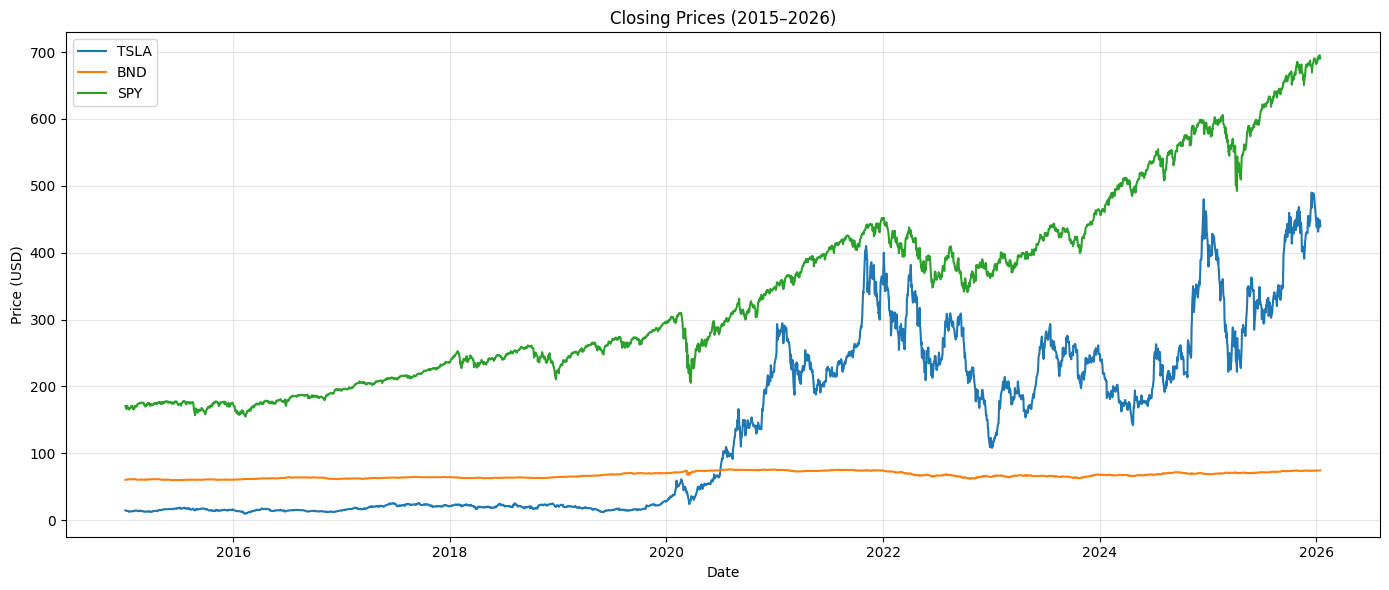

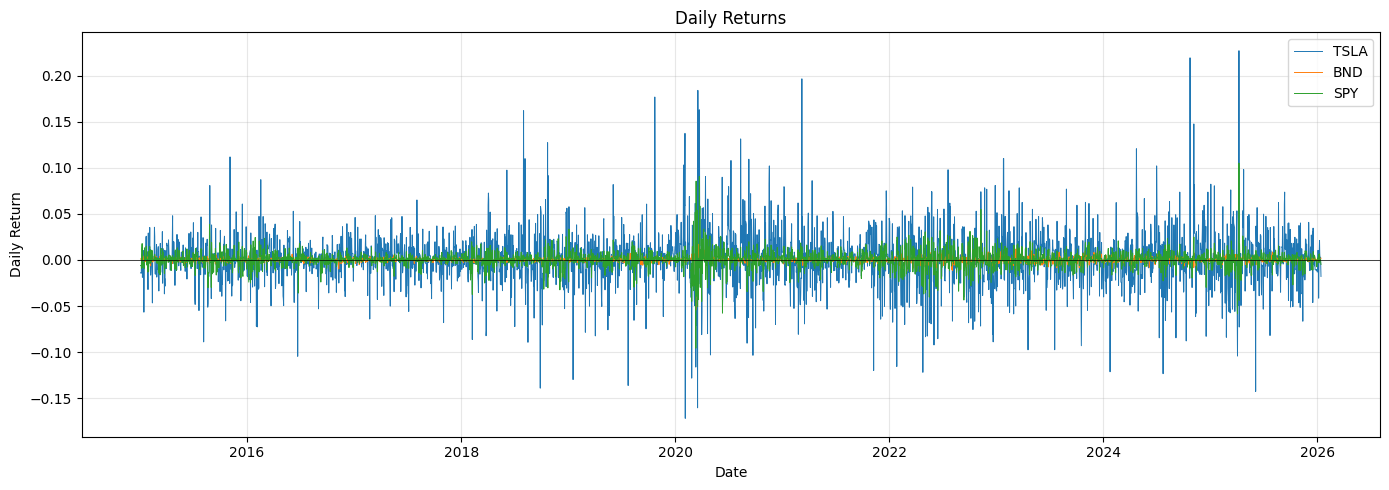

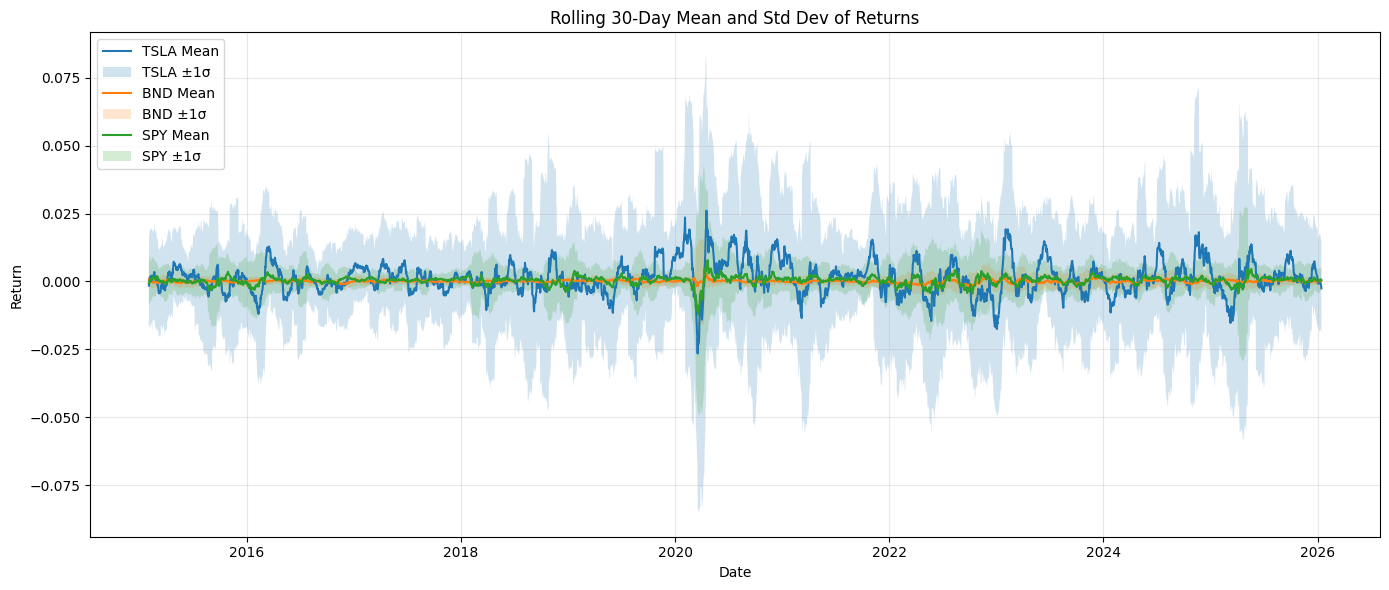


Top 5 Outliers for TSLA:
Date
2015-06-17    0.028801
2015-07-02    0.040386
2015-08-06   -0.088846
2015-10-20   -0.066068
2015-11-04    0.111735
Name: Close, dtype: float64

Top 5 Outliers for BND:
Date
2015-12-01    0.003784
2015-12-03   -0.007746
2016-05-18   -0.004700
2016-06-03    0.006278
2016-06-24    0.005647
Name: Close, dtype: float64

Top 5 Outliers for SPY:
Date
2015-03-06   -0.014065
2015-03-10   -0.016222
2015-08-20   -0.020881
2015-08-21   -0.030103
2015-08-26    0.038394
Name: Close, dtype: float64


{'TSLA': Date
 2025-04-09    0.226900
 2024-10-24    0.219190
 2021-03-09    0.196412
 2019-10-24    0.176692
 2020-02-05   -0.171758
 Name: Close, dtype: float64,
 'BND': Date
 2020-03-12   -0.054385
 2020-03-13    0.042201
 2022-11-10    0.020702
 2020-03-11   -0.018940
 2022-09-28    0.015543
 Name: Close, dtype: float64,
 'SPY': Date
 2025-04-09    0.105019
 2020-03-12   -0.095677
 2025-04-04   -0.058543
 2020-06-11   -0.057649
 2022-11-10    0.054954
 Name: Close, dtype: float64}

In [7]:
eda = EDA(data)
eda.plot_closing_prices()
eda.plot_daily_returns()
eda.plot_rolling_stats(window=30)
eda.detect_outliers(threshold=3)

4. Stationarity & Risk Check

In [8]:
from src import EDA, StationarityTester, RiskMetrics

tester = StationarityTester()
metrics = RiskMetrics()

for ticker, df in data.items():
    price = df['Close']
    returns = price.pct_change().dropna()
    
    # Stationarity
    tester.adf_test(price, f"{ticker} Price")
    tester.adf_test(returns, f"{ticker} Returns")
    
    # Risk
    var = metrics.value_at_risk(returns)
    sharpe = metrics.sharpe_ratio(returns)
    print(f"\n{ticker} Risk Metrics:")
    print(f"  VaR (95%): {var:.4f}")
    print(f"  Sharpe Ratio: {sharpe:.2f}\n")

ADF Test for TSLA Price:
  ADF Statistic: -0.649154
  p-value: 0.8594841670
  Stationary: No

ADF Test for TSLA Returns:
  ADF Statistic: -13.027995
  p-value: 0.0000000000
  Stationary: Yes


TSLA Risk Metrics:
  VaR (95%): -0.0406
  Sharpe Ratio: 0.71

ADF Test for BND Price:
  ADF Statistic: -1.090453
  p-value: 0.7188640645
  Stationary: No

ADF Test for BND Returns:
  ADF Statistic: -21.433664
  p-value: 0.0000000000
  Stationary: Yes


BND Risk Metrics:
  VaR (95%): -0.0034
  Sharpe Ratio: 0.34

ADF Test for SPY Price:
  ADF Statistic: 1.267987
  p-value: 0.9964235399
  Stationary: No

ADF Test for SPY Returns:
  ADF Statistic: -14.464655
  p-value: 0.0000000000
  Stationary: Yes


SPY Risk Metrics:
  VaR (95%): -0.0122
  Sharpe Ratio: 0.71

